In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
qubit_counts = [2,3,4,5,6,7,8,10,12,14,16]

layer_counts = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]
n_trials = 750

In [3]:
def create_circuit(n_qubits, n_layers):

    dev = qml.device("lightning.qubit",wires = n_qubits, c_dtype=np.complex64)

    @qml.qnode(dev, diff_method="adjoint")
    def circuit(weights):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(weights[layer, q],wires=q)

            for q in range(n_qubits-1):
                qml.CNOT(wires=[q,q + 1])
                
        return qml.expval(qml.PauliZ(0))
    return circuit

In [4]:
def run_experiment(n_qubits, n_layers, n_trials):

    circuit = create_circuit(n_qubits,n_layers)
    
    all_gradients = []
    
    
    for trial in range(n_trials):
        weights = np.array(np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits)),requires_grad=True)
        # old weights = np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits),requires_grad=True)
        gradient = qml.grad(circuit)(weights)

        all_gradients.append(gradient)
        
    #qml.draw_mpl(circuit,style='pennylane')(weights);
    
    return np.array(all_gradients)

In [5]:
results = []

for n_layers in layer_counts:

    print(f"Running {n_layers} layers...")
    
    for n_qubits in qubit_counts:

        #print(f"Running {n_qubits} qubits...")

        gradients = run_experiment(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)
        parameter_var = np.var(gradients,axis=0)
        mean_var = np.mean(parameter_var)

        results.append({"Layers": n_layers,"Qubits": n_qubits,"Variance": mean_var})

        #print(f"Mean grad variance: "f"{mean_var:.6e}")

Running 2 layers...
Running 3 layers...
Running 4 layers...
Running 5 layers...
Running 6 layers...
Running 7 layers...
Running 8 layers...
Running 9 layers...
Running 10 layers...
Running 11 layers...
Running 12 layers...
Running 13 layers...
Running 14 layers...
Running 15 layers...


,Layers,Qubits,Variance
0,2,2,0.21027632616708697
1,2,3,0.15790736832416186
2,2,4,0.10894985994868228
3,2,5,0.08451532913941469
4,2,6,0.0730403265222883
...,...,...,...
149,15,8,0.0032753352823950864
150,15,10,0.0016321977614735664
151,15,12,0.0012066355771724933
152,15,14,0.0010878593609610376


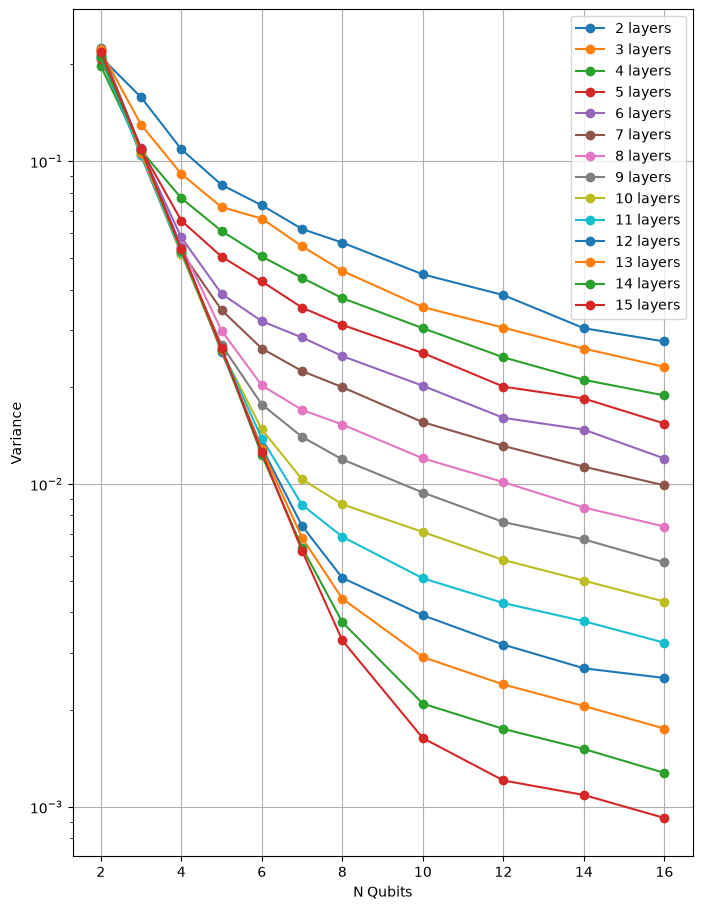

In [6]:
results_df = pd.DataFrame(results)

display(results_df)

plt.figure(figsize=(8,len(qubit_counts)))

for n_layers in layer_counts:

    data = results_df[results_df["Layers"] == n_layers]
    plt.plot(data["Qubits"],data["Variance"],marker="o",label=f"{n_layers} layers")

plt.yscale("log")

plt.xlabel("N Qubits")
plt.ylabel("Variance")

plt.grid(True)
plt.legend()
plt.show()